In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print(df.shape)
print(df.info())
print(df.describe())

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842 

In [3]:
# 1. Fill missing Age with mean
df["Age"] = df["Age"].fillna(df["Age"].mean())

# 2. Drop the Cabin column entirely
df = df.drop(columns=["Cabin"])

# 3. Fill missing Embarked with most common value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Check no missing values remain
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
#Question 1: What was the overall survival rate?
survival_rate = df["Survived"].mean() * 100
print(f"Survival rate: {survival_rate:.1f}%")

Survival rate: 38.4%


In [8]:
#Question 2: Did women survive more than men?
women_survived=df.groupby("Sex")["Survived"].mean()*100
print(women_survived)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [10]:
#Question 3: Did passenger class affect survival?
Class_survival=df.groupby("Pclass")["Survived"].mean()*100
print(Class_survival)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


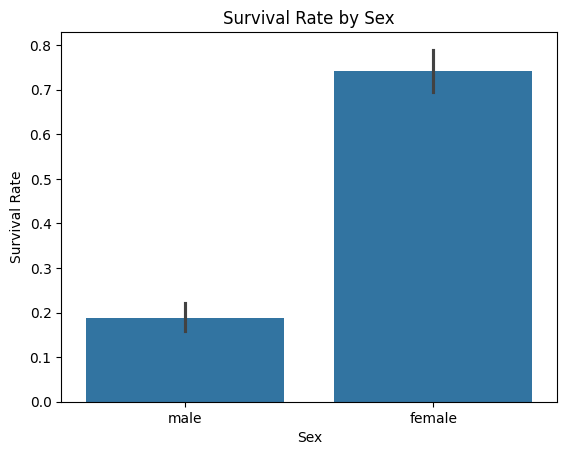

In [11]:
#Chart 1 — Survival by sex:
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

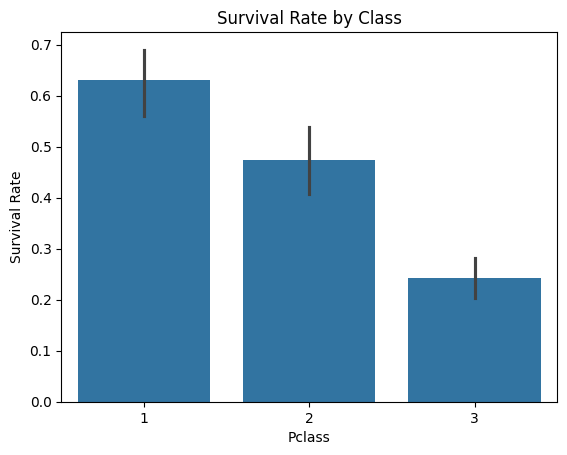

In [12]:
#Chart 2 — Survival by class
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("Survival Rate by Class")
plt.ylabel("Survival Rate")
plt.show()

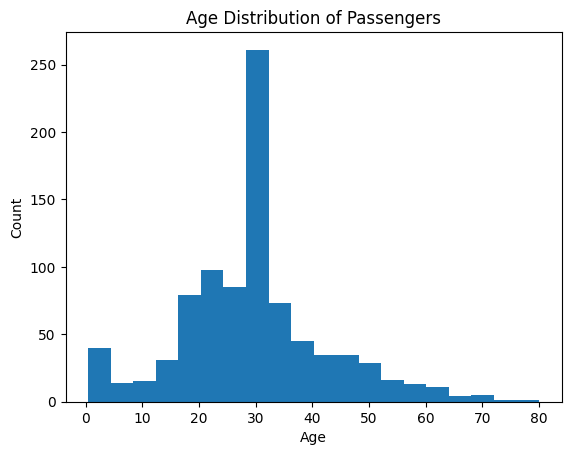

In [13]:
#Question 4: What was the age distribution of passengers?
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

<Axes: xlabel='Survived', ylabel='Age'>

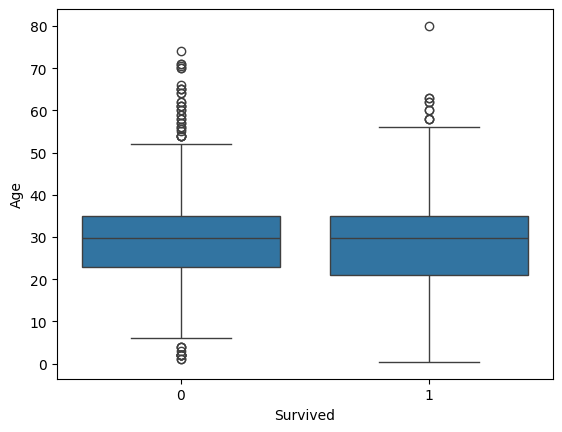

In [14]:
#Question 5: Did age differ between survivors and non-survivors?
sns.boxplot(data=df, x="Survived", y="Age")